# 05. XGBoost 모델

## 목표
- XGBoost gradient boosting으로 일별 매출 예측
- Optuna 하이퍼파라미터 튜닝 (50 trials)
- SHAP Feature Importance 분석

## 접근 방식
- **Single Global Model**: 5개 상품군 데이터를 합치고 `family`를 label encoding하여 단일 모델 학습
- 기존 `feature_engineering.py`의 Lag/Rolling/EWM 피쳐 활용
- TimeSeriesSplit(5)으로 시계열 교차검증

In [1]:
import sys
import warnings

warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import optuna
from sklearn.preprocessing import LabelEncoder

# 한글 폰트 설정
fm._load_fontmanager(try_read_cache=False)
sns.set_style("whitegrid")
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 프로젝트 모듈
sys.path.insert(0, "..")
from src.feature_engineering import create_all_features
from src.evaluation import evaluate_model
from src.models.xgboost_model import XGBoostModel

optuna.logging.set_verbosity(optuna.logging.WARNING)
print("Setup complete")

Setup complete


## 1. 데이터 로드 + 피쳐 엔지니어링

In [2]:
# 전처리된 데이터 로드
train = pd.read_csv("../data/processed/train.csv", parse_dates=["date"])
val = pd.read_csv("../data/processed/val.csv", parse_dates=["date"])
test = pd.read_csv("../data/processed/test.csv", parse_dates=["date"])
top_families = pd.read_csv("../data/processed/top_families.csv")["family"].tolist()

# 전체 데이터 합쳐서 피쳐 생성 (lag 계산에 train 기간 데이터 필요)
full = pd.concat([train, val, test], ignore_index=True)
full = full.sort_values(["family", "date"]).reset_index(drop=True)

# Lag, Rolling, EWM 피쳐 생성
full = create_all_features(full)

print(f"Full data shape: {full.shape}")
print(f"Top 5 families: {top_families}")
print(
    f"\nNew features: {[c for c in full.columns if c.startswith(('lag_', 'rolling_', 'ewm_'))]}"
)
print(
    f"NaN count after feature engineering:\n{full.isnull().sum()[full.isnull().sum() > 0]}"
)

Full data shape: (8420, 29)
Top 5 families: ['GROCERY I', 'BEVERAGES', 'PRODUCE', 'CLEANING', 'DAIRY']

New features: ['lag_7', 'lag_14', 'lag_28', 'lag_365', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_30', 'rolling_std_30', 'ewm_mean_7', 'ewm_mean_30']
NaN count after feature engineering:
holiday_type       7740
lag_7                35
lag_14               70
lag_28              140
lag_365            1825
rolling_mean_7       35
rolling_std_7        35
rolling_mean_30     150
rolling_std_30      150
ewm_mean_7           35
ewm_mean_30         150
dtype: int64


In [3]:
# Family label encoding
le = LabelEncoder()
full["family_encoded"] = le.fit_transform(full["family"])
print(f"Family encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# 피쳐 컴럼 정의 (date, family, sales, day_name, holiday_type 제외)
exclude_cols = ["date", "family", "sales", "day_name", "holiday_type", "year"]
feature_cols = [c for c in full.columns if c not in exclude_cols]
print(f"\nFeature columns ({len(feature_cols)}):")
for i, col in enumerate(feature_cols):
    print(f"  {i + 1}. {col}")

Family encoding: {'BEVERAGES': np.int64(0), 'CLEANING': np.int64(1), 'DAIRY': np.int64(2), 'GROCERY I': np.int64(3), 'PRODUCE': np.int64(4)}

Feature columns (24):
  1. onpromotion
  2. oil_price
  3. is_holiday
  4. total_transactions
  5. month
  6. day
  7. day_of_week
  8. week_of_year
  9. quarter
  10. is_weekend
  11. is_month_start
  12. is_month_end
  13. day_of_year
  14. lag_7
  15. lag_14
  16. lag_28
  17. lag_365
  18. rolling_mean_7
  19. rolling_std_7
  20. rolling_mean_30
  21. rolling_std_30
  22. ewm_mean_7
  23. ewm_mean_30
  24. family_encoded


In [4]:
# 시간 기준으로 다시 분할
train_feat = full[full["date"] <= "2016-12-31"].copy()
val_feat = full[(full["date"] >= "2017-01-01") & (full["date"] <= "2017-06-30")].copy()
test_feat = full[full["date"] >= "2017-07-01"].copy()

# NaN 제거 (lag_365로 인한 첫 1년)
train_feat = train_feat.dropna(subset=feature_cols)
val_feat = val_feat.dropna(subset=feature_cols)
test_feat = test_feat.dropna(subset=feature_cols)

# X, y 분리
X_train = train_feat[feature_cols]
y_train = train_feat["sales"]
X_val = val_feat[feature_cols]
y_val = val_feat["sales"]
X_test = test_feat[feature_cols]
y_test = test_feat["sales"]

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}, y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")
print(f"\nTrain date range: {train_feat['date'].min()} ~ {train_feat['date'].max()}")
print(f"Val date range:   {val_feat['date'].min()} ~ {val_feat['date'].max()}")

X_train: (5460, 24), y_train: (5460,)
X_val:   (905, 24), y_val:   (905,)
X_test:  (230, 24), y_test:  (230,)

Train date range: 2014-01-02 00:00:00 ~ 2016-12-31 00:00:00
Val date range:   2017-01-01 00:00:00 ~ 2017-06-30 00:00:00


## 2. 베이스라인 XGBoost (기본 파라미터)

먼저 기본 하이퍼파라미터로 XGBoost를 학습하여 베이스라인 성능을 확인한다.

In [5]:
# 베이스라인 XGBoost (기본 파라미터)
baseline_model = XGBoostModel()
baseline_model.fit(X_train, y_train, X_val, y_val)
baseline_preds = baseline_model.predict(X_val)

# 상품군별 MAPE 계산
baseline_results = []
for family in top_families:
    mask = val_feat["family"] == family
    if mask.sum() == 0:
        continue
    result = evaluate_model(
        y_val[mask].values,
        baseline_preds[mask],
        model_name="XGBoost_Baseline",
        family=family,
        train_time=baseline_model.train_time_,
        predict_time=baseline_model.predict_time_,
    )
    baseline_results.append(result)

baseline_df = pd.DataFrame(baseline_results)
print("=== XGBoost Baseline (기본 파라미터) ===")
print(baseline_df[["model", "family", "mape", "rmse", "mae"]].to_string(index=False))
print(f"\nAvg MAPE: {baseline_df['mape'].mean():.2f}%")
print(f"Train time: {baseline_model.train_time_:.2f}s")

=== XGBoost Baseline (기본 파라미터) ===
           model    family      mape         rmse          mae
XGBoost_Baseline GROCERY I 53.537910 25768.902920 16528.201077
XGBoost_Baseline BEVERAGES 29.775108 21988.840601 13574.994907
XGBoost_Baseline   PRODUCE 35.761224 14049.948941  8953.460299
XGBoost_Baseline  CLEANING 84.843743  8429.684924  5415.684198
XGBoost_Baseline     DAIRY 51.579198  6039.011503  3956.311723

Avg MAPE: 51.10%
Train time: 0.56s


## 3. Optuna 하이퍼파라미터 튜닝

50회 trial로 최적 파라미터를 탐색한다. TimeSeriesSplit(5)으로 시계열 무결성을 유지하면서 교차검증한다.

### 탐색 공간
| 파라미터 | 범위 |
|----------|------|
| n_estimators | [100, 1000] |
| max_depth | [3, 10] |
| learning_rate | [0.01, 0.3] (log) |
| subsample | [0.6, 1.0] |
| colsample_bytree | [0.6, 1.0] |
| min_child_weight | [1, 10] |
| reg_alpha | [0, 10] |
| reg_lambda | [0, 10] |

In [6]:
import numpy as np
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from src.evaluation import mape


def objective(trial):
    """Optuna objective: TimeSeriesSplit CV MAPE 최소화."""
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 10),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 10),
        "random_state": 42,
        "n_jobs": -1,
    }

    # TimeSeriesSplit on training data
    tscv = TimeSeriesSplit(n_splits=5)
    mape_scores = []

    for train_idx, val_idx in tscv.split(X_train):
        X_tr, X_vl = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_vl = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = xgb.XGBRegressor(**params)
        model.fit(X_tr, y_tr, eval_set=[(X_vl, y_vl)], verbose=False)
        preds = model.predict(X_vl)

        score = mape(y_vl.values, preds)
        if not np.isnan(score):
            mape_scores.append(score)

    return np.mean(mape_scores) if mape_scores else float("inf")


# Optuna 최적화 실행
study = optuna.create_study(direction="minimize", study_name="xgboost_tuning")
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("\n=== Optuna 결과 ===")
print(f"Best MAPE (CV): {study.best_value:.2f}%")
print("Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

  0%|          | 0/50 [00:00<?, ?it/s]


=== Optuna 결과 ===
Best MAPE (CV): 1070.36%
Best params:
  n_estimators: 649
  max_depth: 10
  learning_rate: 0.010421382051795
  subsample: 0.9710472046599186
  colsample_bytree: 0.9862401182205974
  min_child_weight: 7
  reg_alpha: 1.9695009389290088
  reg_lambda: 8.054572741435909


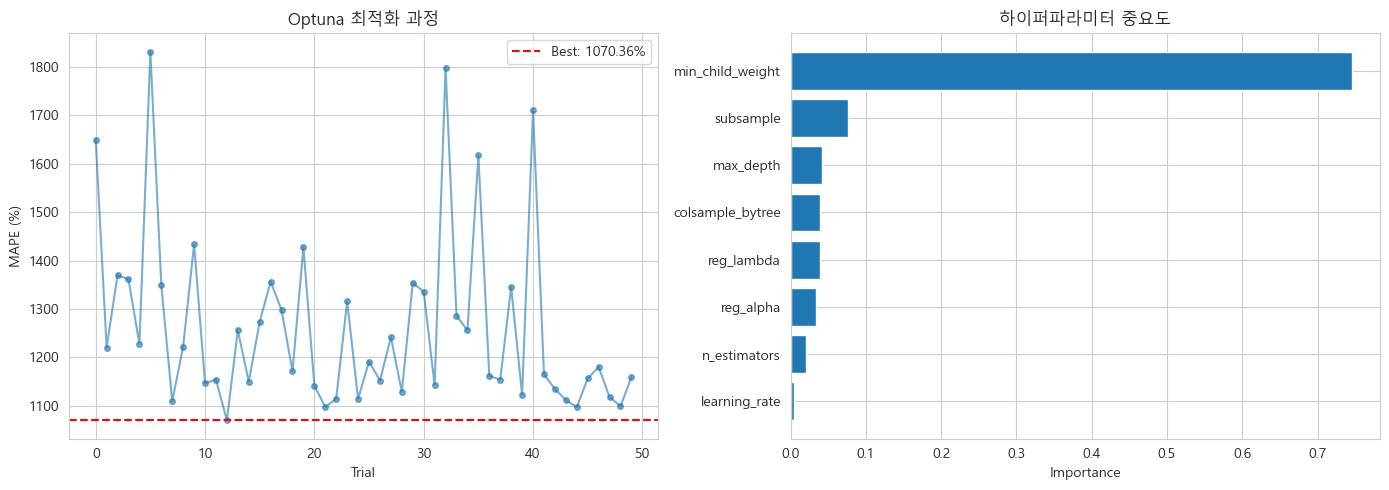

In [7]:
# 최적화 과정 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Trial history
trials_df = study.trials_dataframe()
axes[0].plot(trials_df["number"], trials_df["value"], "o-", alpha=0.6, markersize=4)
axes[0].axhline(
    y=study.best_value,
    color="r",
    linestyle="--",
    label=f"Best: {study.best_value:.2f}%",
)
axes[0].set_xlabel("Trial")
axes[0].set_ylabel("MAPE (%)")
axes[0].set_title("Optuna 최적화 과정")
axes[0].legend()

# Parameter importance (top 5)
importances = optuna.importance.get_param_importances(study)
top_params = dict(list(importances.items())[:8])
axes[1].barh(list(top_params.keys())[::-1], list(top_params.values())[::-1])
axes[1].set_xlabel("Importance")
axes[1].set_title("하이퍼파라미터 중요도")

plt.tight_layout()
plt.savefig("../outputs/figures/18_optuna_history.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. 최적 모델 재학습 + Validation 평가

In [8]:
# 최적 파라미터로 전체 train 데이터에 대해 재학습
best_params = {**study.best_params, "random_state": 42, "n_jobs": -1}
tuned_model = XGBoostModel(params=best_params)
tuned_model.fit(X_train, y_train, X_val, y_val)
tuned_preds = tuned_model.predict(X_val)

# 상품군별 평가
tuned_results = []
for family in top_families:
    mask = val_feat["family"] == family
    if mask.sum() == 0:
        continue
    result = evaluate_model(
        y_val[mask].values,
        tuned_preds[mask],
        model_name="XGBoost_Tuned",
        family=family,
        train_time=tuned_model.train_time_,
        predict_time=tuned_model.predict_time_,
    )
    tuned_results.append(result)

tuned_df = pd.DataFrame(tuned_results)
print("=== XGBoost Tuned (Optuna 최적) ===")
print(tuned_df[["model", "family", "mape", "rmse", "mae"]].to_string(index=False))
print(f"\nAvg MAPE: {tuned_df['mape'].mean():.2f}%")
print(f"Train time: {tuned_model.train_time_:.2f}s")

# Baseline vs Tuned 비교
print("\n=== Baseline vs Tuned ===")
comparison = baseline_df[["family", "mape"]].rename(columns={"mape": "baseline_mape"})
comparison = comparison.merge(
    tuned_df[["family", "mape"]].rename(columns={"mape": "tuned_mape"}), on="family"
)
comparison["improvement"] = comparison["baseline_mape"] - comparison["tuned_mape"]
print(comparison.to_string(index=False))

=== XGBoost Tuned (Optuna 최적) ===
        model    family      mape         rmse          mae
XGBoost_Tuned GROCERY I 52.848239 30101.333165 18626.374548
XGBoost_Tuned BEVERAGES 26.010451 22802.025665 14784.848325
XGBoost_Tuned   PRODUCE 25.056474 16515.031431 11112.817435
XGBoost_Tuned  CLEANING 88.977867  8551.180603  5128.820054
XGBoost_Tuned     DAIRY 49.628616  6049.032794  3994.047458

Avg MAPE: 48.50%
Train time: 1.26s

=== Baseline vs Tuned ===
   family  baseline_mape  tuned_mape  improvement
GROCERY I      53.537910   52.848239     0.689671
BEVERAGES      29.775108   26.010451     3.764658
  PRODUCE      35.761224   25.056474    10.704750
 CLEANING      84.843743   88.977867    -4.134124
    DAIRY      51.579198   49.628616     1.950582


## 5. SHAP Feature Importance

TreeExplainer를 사용하여 각 피처가 예측에 미치는 영향을 분석한다.
- **Summary plot (beeswarm)**: 피처별 SHAP value 분포. 색상은 피처 값의 크기를 나타낸다.
- **Bar plot**: 전체 피처 중요도 순위 (|SHAP value| 평균).

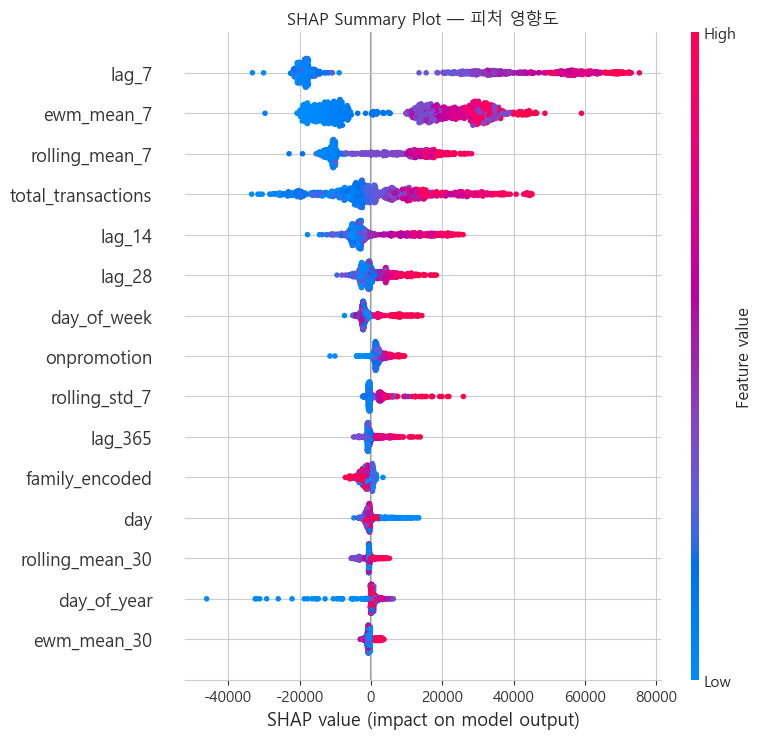

In [9]:
import shap

# SHAP values 계산 (validation set)
shap_values = tuned_model.get_shap_values(X_val)

# Summary plot (beeswarm)
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, X_val, max_display=15, show=False)
plt.title("SHAP Summary Plot — 피처 영향도")
plt.tight_layout()
plt.savefig("../outputs/figures/19_shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

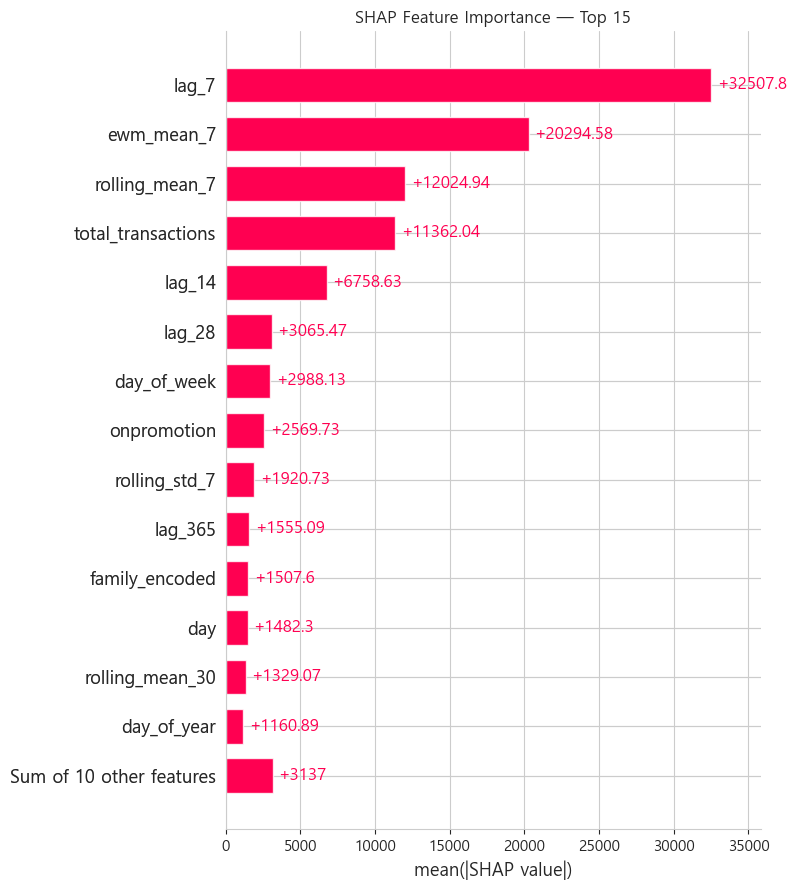

In [10]:
# Bar plot (mean |SHAP value|)
fig, ax = plt.subplots(figsize=(10, 6))
shap.plots.bar(shap_values, max_display=15, show=False)
plt.title("SHAP Feature Importance — Top 15")
plt.tight_layout()
plt.savefig("../outputs/figures/20_shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. 예측 시각화

상품군별로 Validation 기간의 실제 매출과 XGBoost 예측값을 비교한다.

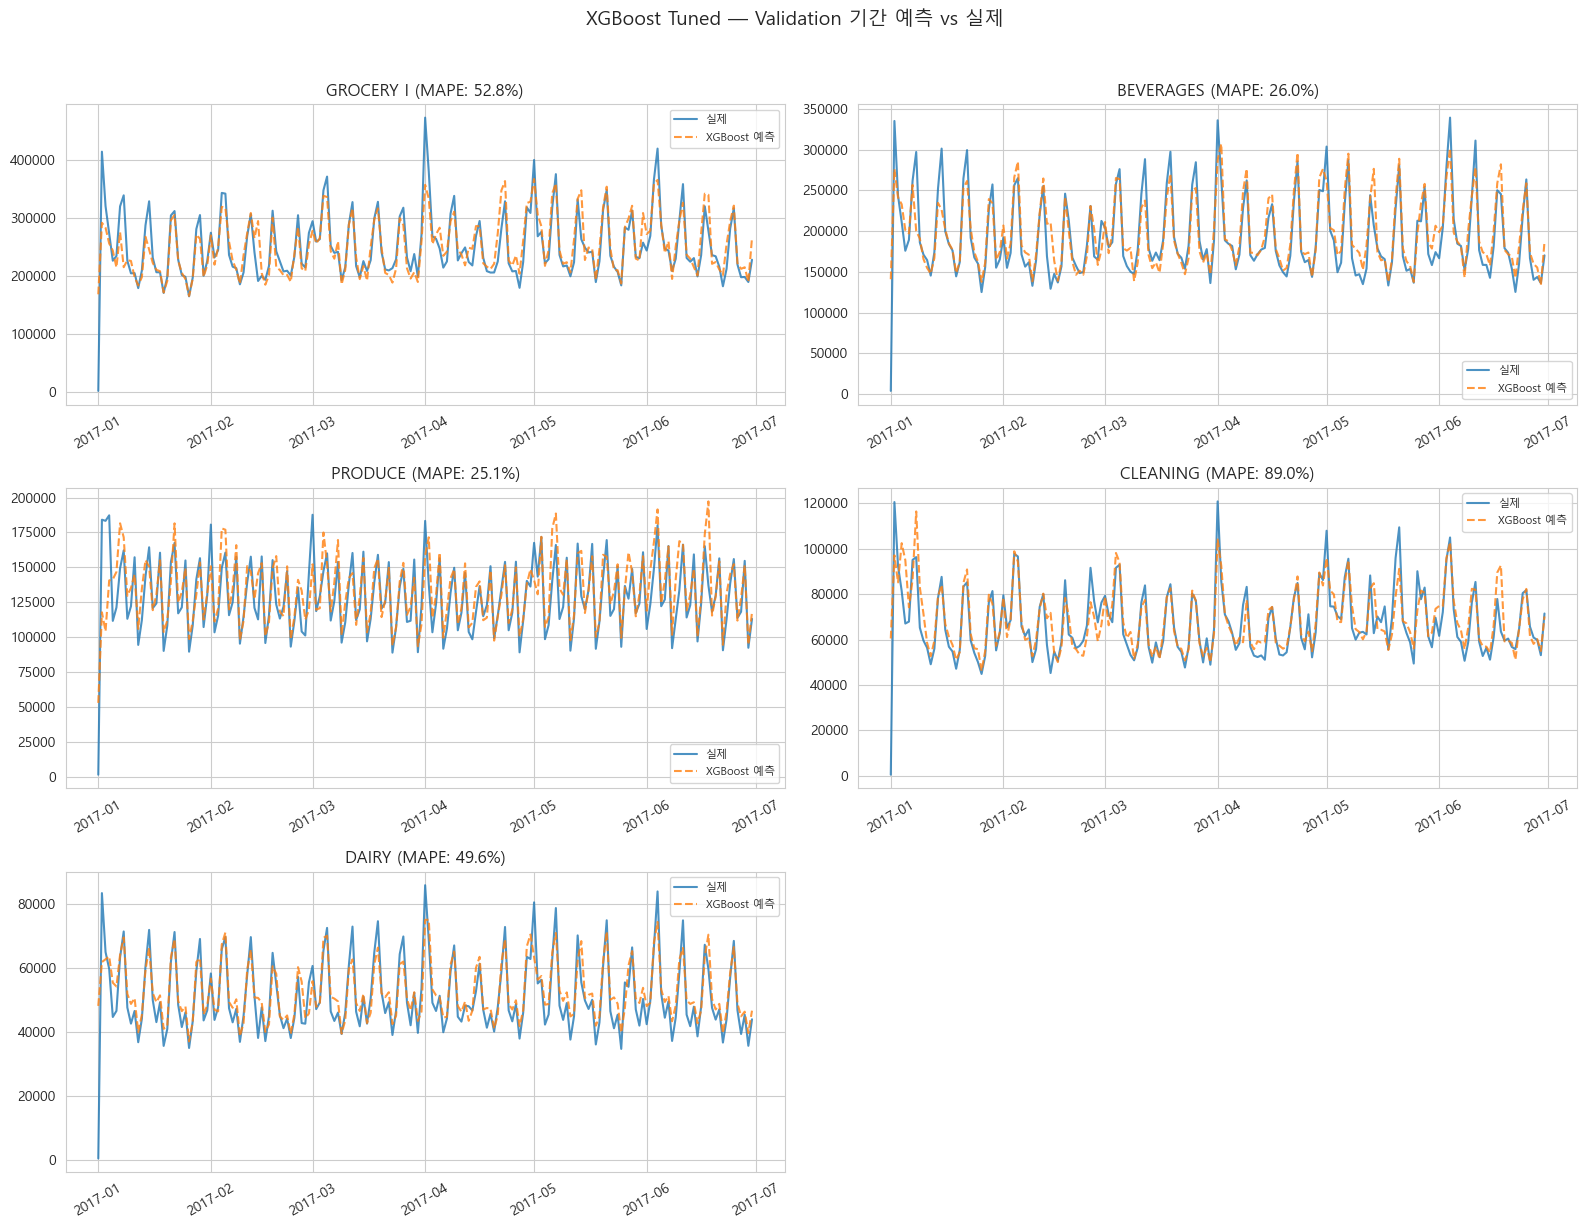

In [11]:
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

for i, family in enumerate(top_families):
    ax = axes[i]
    mask = val_feat["family"] == family
    dates = val_feat.loc[mask, "date"]
    actual = y_val[mask].values
    predicted = tuned_preds[mask]

    ax.plot(dates, actual, label="실제", alpha=0.8)
    ax.plot(dates, predicted, label="XGBoost 예측", alpha=0.8, linestyle="--")
    ax.set_title(f"{family} (MAPE: {mape(actual, predicted):.1f}%)")
    ax.legend(fontsize=8)
    ax.tick_params(axis="x", rotation=30)

# 빈 subplot 제거
axes[5].set_visible(False)

plt.suptitle("XGBoost Tuned — Validation 기간 예측 vs 실제", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../outputs/figures/18_xgboost_forecast.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. 결과 저장

In [12]:
# 결과 CSV 저장 (baseline + tuned)
all_results = pd.concat([baseline_df, tuned_df], ignore_index=True)
all_results.to_csv("../outputs/results/xgboost_results.csv", index=False)
print(f"Results saved: outputs/results/xgboost_results.csv ({len(all_results)} rows)")

# Test set 예측도 미리 저장 (06_comparison에서 사용)
test_preds = tuned_model.predict(X_test)
test_results = []
for family in top_families:
    mask = test_feat["family"] == family
    if mask.sum() == 0:
        continue
    result = evaluate_model(
        y_test[mask].values,
        test_preds[mask],
        model_name="XGBoost_Tuned",
        family=family,
        train_time=tuned_model.train_time_,
        predict_time=tuned_model.predict_time_,
    )
    test_results.append(result)

test_df = pd.DataFrame(test_results)
print("\n=== Test Set 평가 (참고) ===")
print(test_df[["model", "family", "mape", "rmse", "mae"]].to_string(index=False))

# Validation 예측값 저장 (앙상블용)
val_predictions = val_feat[["date", "family"]].copy()
val_predictions["xgboost_pred"] = tuned_preds
val_predictions.to_csv("../outputs/results/xgboost_val_predictions.csv", index=False)

# Test 예측값 저장
test_predictions = test_feat[["date", "family"]].copy()
test_predictions["xgboost_pred"] = test_preds
test_predictions.to_csv("../outputs/results/xgboost_test_predictions.csv", index=False)

print("\nAll outputs saved.")

Results saved: outputs/results/xgboost_results.csv (10 rows)

=== Test Set 평가 (참고) ===
        model    family      mape         rmse          mae
XGBoost_Tuned GROCERY I  7.489018 22239.834332 18637.663967
XGBoost_Tuned BEVERAGES  7.662569 17835.862473 14745.734715
XGBoost_Tuned   PRODUCE  6.443721 11322.108561  8306.409978
XGBoost_Tuned  CLEANING 11.668107 10466.062748  8204.814963
XGBoost_Tuned     DAIRY  7.697935  4297.458346  3616.868971

All outputs saved.


## 요약

### XGBoost 결과
- **Single Global Model**: 5개 상품군을 합쳐 학습, family를 label encoding
- **Optuna 50 trials**: TimeSeriesSplit(5) 기반 교차검증으로 하이퍼파라미터 최적화
- **SHAP 분석**: lag, rolling 피처가 가장 중요한 역할

### 다음 단계
→ `06_model_comparison.ipynb`에서 SARIMA, Prophet, XGBoost 3모델 + 앙상블 비교